In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [2]:
class GreetState(BaseModel):
    message:str =""

In [3]:
graph = StateGraph(GreetState)

In [4]:
#### Nodes - Python Function

In [5]:
def Greet(state:GreetState):
    state.message = f"{state.message} ! All Good !"
    return state


def upperCase(state:GreetState):
    state.messages = state.message.upper()
    return state

In [6]:
graph.add_node("greet", Greet)

In [9]:
graph.add_node("upper_case", upperCase)

In [13]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upper_case")
graph.add_edge("greet", "upper_case")
graph.add_edge("upper_case", END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [19]:
finalGraph = graph.compile()

In [22]:
res = finalGraph.invoke({"messages":"I Love LangGraph !"})


ValueError: "GreetState" object has no field "messages"

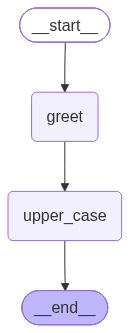

In [23]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())